# Dimensionality Reduction using Principal component analysis (3D >> 2D)

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.decomposition import PCA

## Generate Random 3D Data

In [2]:
np.random.seed(42)
X = np.random.multivariate_normal(mean=[0, 0, 0], cov=[[5, 2, 1], [2, 4, 1], [1, 1, 3]], size=200)  # Generating Random Data For our uasge

print(f"Generated Data Shape: {X.shape}\n")
print(f"First 5 Data Points:\n{X[:5]}\n")
print(f"Mean of Data: {X.mean(axis=0)}\n")
print(f"Covariance Matrix Used:\n{[[5, 2, 1], [2, 4, 1], [1, 1, 3]]}")

Generated Data Shape: (200, 3)

First 5 Data Points:
[[-0.78202128 -1.43083939  0.31466081]
 [-3.32169587 -2.00281174 -1.25591805]
 [-2.58652337 -2.36155469 -2.71619378]
 [-1.73893643 -0.08279495 -0.33537645]
 [-3.17127984  2.57179083  0.53295466]]

Mean of Data: [-0.24151541 -0.06881062  0.16100108]

Covariance Matrix Used:
[[5, 2, 1], [2, 4, 1], [1, 1, 3]]


## Plot Original 3D Data

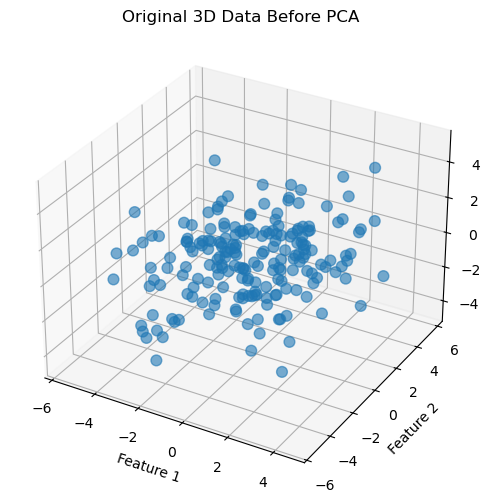

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], alpha=0.6, s=60)
ax.set_title("Original 3D Data Before PCA")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.show()

## Apply PCA

In [4]:
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

print(f"PCA Components (Eigenvectors):\n{pca.components_}\n")
print(f"Explained Variance (Eigenvalues):\n{pca.explained_variance_}\n")
print(f"Transformed Data Shape (X_pca): {X_pca.shape}\n")
print(f"First 5 Transformed Data Points:\n{X_pca[:5]}")

PCA Components (Eigenvectors):
[[ 0.72685412  0.55697887  0.40181791]
 [-0.47577259 -0.01358557  0.8794634 ]]

Explained Variance (Eigenvalues):
[5.64608247 2.72164693]

Transformed Data Shape (X_pca): (200, 2)

First 5 Transformed Data Points:
[[-1.08974693  0.41079992]
 [-3.88538309  0.24561144]
 [-4.13759712 -1.38354882]
 [-1.295649    0.27607599]
 [-0.50929454  1.68514711]]


## Visualize Reduced Data and Eigenvectors

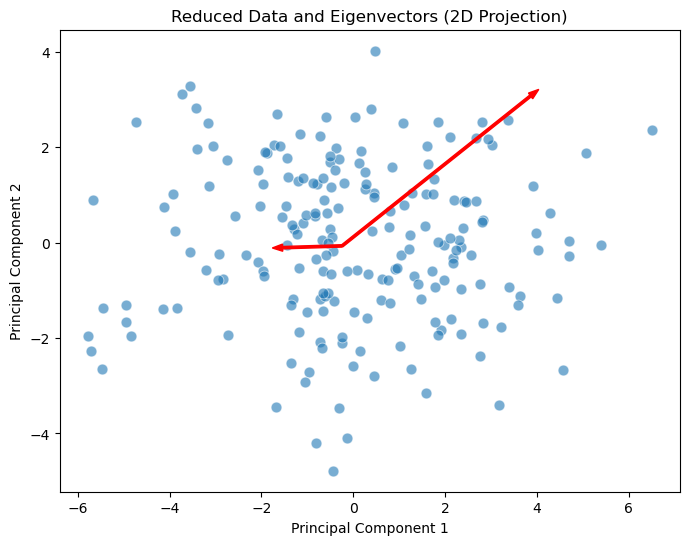

Mean of Original Data (First 2 Dimensions, Arrow Start): [-0.24151541 -0.06881062]

Principal Components (Vectors) and Variances (Scaled):

Component 1: Vector = [0.72685412 0.55697887 0.40181791], Variance = 5.64608247493023

Component 2: Vector = [-0.47577259 -0.01358557  0.8794634 ], Variance = 2.721646932097374



In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.6, s=60)  # uor reduced 2d data

mean_2d = X.mean(axis=0)[:2]  # first 2 dimensions for plot
for vec, val in zip(
    pca.components_,  # principal axes like eigenvectors
    pca.explained_variance_  # variance along each axis like uor eigenvalues
):
    plt.arrow(mean_2d[0], mean_2d[1], vec[0] * val, vec[1] * val, color='red', width=0.05)

plt.title("Reduced Data and Eigenvectors (2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# visualization details
print(f"Mean of Original Data (First 2 Dimensions, Arrow Start): {mean_2d}\n")
print(f"Principal Components (Vectors) and Variances (Scaled):\n")
for i, (v, e) in enumerate(zip(pca.components_, pca.explained_variance_)):
    print(f"Component {i+1}: Vector = {v}, Variance = {e}\n")